In [599]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

In [600]:

ruta = "fp.csv"
df = pd.read_csv(ruta)



In [601]:
df.head(10)

,id,Project,TeamExp,ManagerExp,YearEnd,Length,Effort,Transactions,Entities,PointsNonAdjust,Adjustment,PointsAjust,Language
0,1,1,1,4,85,12,5152,253,52,305,34,302,1
1,2,2,0,0,86,4,5635,197,124,321,33,315,1
2,3,3,4,4,85,1,805,40,60,100,18,83,1
3,4,4,0,0,86,5,3829,200,119,319,30,303,1
4,5,5,0,0,86,4,2149,140,94,234,24,208,1
5,6,6,0,0,86,4,2821,97,89,186,38,192,1
6,7,7,2,1,85,9,2569,119,42,161,25,145,2
7,8,8,1,2,83,13,3913,186,52,238,25,214,1
8,9,9,3,1,85,12,7854,172,88,260,30,247,1
9,10,10,3,4,83,4,2422,78,38,116,24,103,1


In [602]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               81 non-null     int64
 1   Project          81 non-null     int64
 2   TeamExp          81 non-null     int64
 3   ManagerExp       81 non-null     int64
 4   YearEnd          81 non-null     int64
 5   Length           81 non-null     int64
 6   Effort           81 non-null     int64
 7   Transactions     81 non-null     int64
 8   Entities         81 non-null     int64
 9   PointsNonAdjust  81 non-null     int64
 10  Adjustment       81 non-null     int64
 11  PointsAjust      81 non-null     int64
 12  Language         81 non-null     int64
dtypes: int64(13)
memory usage: 8.4 KB


In [603]:
columnas_a_eliminar = ['id', 'Project', 'YearEnd']
df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns], inplace=True)

In [604]:
target = 'Effort' 
features = [col for col in df.columns if col != target]

# Rellenar nulos con la mediana
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

In [605]:
# 5. Iterar sobre cada característica e imprimir sus valores únicos
for feature in features:
    unique_vals = sorted(df[feature].unique())
    print(f"--- {feature} ---")
    print(f"Cantidad de valores únicos: {len(unique_vals)}")
    print(f"Valores: {unique_vals}\n")

--- TeamExp ---
Cantidad de valores únicos: 6
Valores: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

--- ManagerExp ---
Cantidad de valores únicos: 8
Valores: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7)]

--- Length ---
Cantidad de valores únicos: 26
Valores: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(26), np.int64(27), np.int64(34), np.int64(36), np.int64(39)]

--- Transactions ---
Cantidad de valores únicos: 73
Valores: [np.int64(9), np.int64(33), np.int64(40), np.int64(42), np.int64(45), np.int64(47), np.int64(55), np.int64(57), np.int64(58), np.int64(61), np.int64(64), np.int64(68), np.int64(69), np.int64(71), np.int64(74), np.int64(78), n

In [606]:
# 4. Manejo de valores anómalos (-1) en TeamExp y ManagerExp
columnas_con_anomalias = ['TeamExp', 'ManagerExp']

for col in columnas_con_anomalias:
    # Calcular la moda excluyendo los valores -1
    moda_real = df[df[col] != -1][col].mode()[0]
    
    # Reemplazar los -1 con la moda calculada
    df[col] = df[col].replace(-1, moda_real)
    
    print(f"Columna '{col}': Los valores -1 fueron reemplazados por la moda -> {moda_real}")

# 5. Verificación rápida
print("\n--- Verificación de valores únicos actualizados ---")
for col in columnas_con_anomalias:
    valores_actualizados = sorted(df[col].unique())
    print(f"{col}: {valores_actualizados}")

Columna 'TeamExp': Los valores -1 fueron reemplazados por la moda -> 4
Columna 'ManagerExp': Los valores -1 fueron reemplazados por la moda -> 4

--- Verificación de valores únicos actualizados ---
TeamExp: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
ManagerExp: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7)]


In [607]:
df

,TeamExp,ManagerExp,Length,Effort,Transactions,Entities,PointsNonAdjust,Adjustment,PointsAjust,Language
0,1,4,12,5152,253,52,305,34,302,1
1,0,0,4,5635,197,124,321,33,315,1
2,4,4,1,805,40,60,100,18,83,1
3,0,0,5,3829,200,119,319,30,303,1
4,0,0,4,2149,140,94,234,24,208,1
...,...,...,...,...,...,...,...,...,...,...
76,4,4,12,1400,229,169,398,39,414,3
77,4,3,12,2800,227,73,300,34,297,1
78,4,4,24,9520,395,193,588,40,617,1
79,4,3,12,5880,469,176,645,43,697,3


In [608]:
# 5. Configurar el tamaño y la disposición de las subgráficas
num_features = len(features)
cols = 3
rows = int(np.ceil(num_features / cols))

¡Gráfica guardada exitosamente como 'graficas_correlacion.png'!


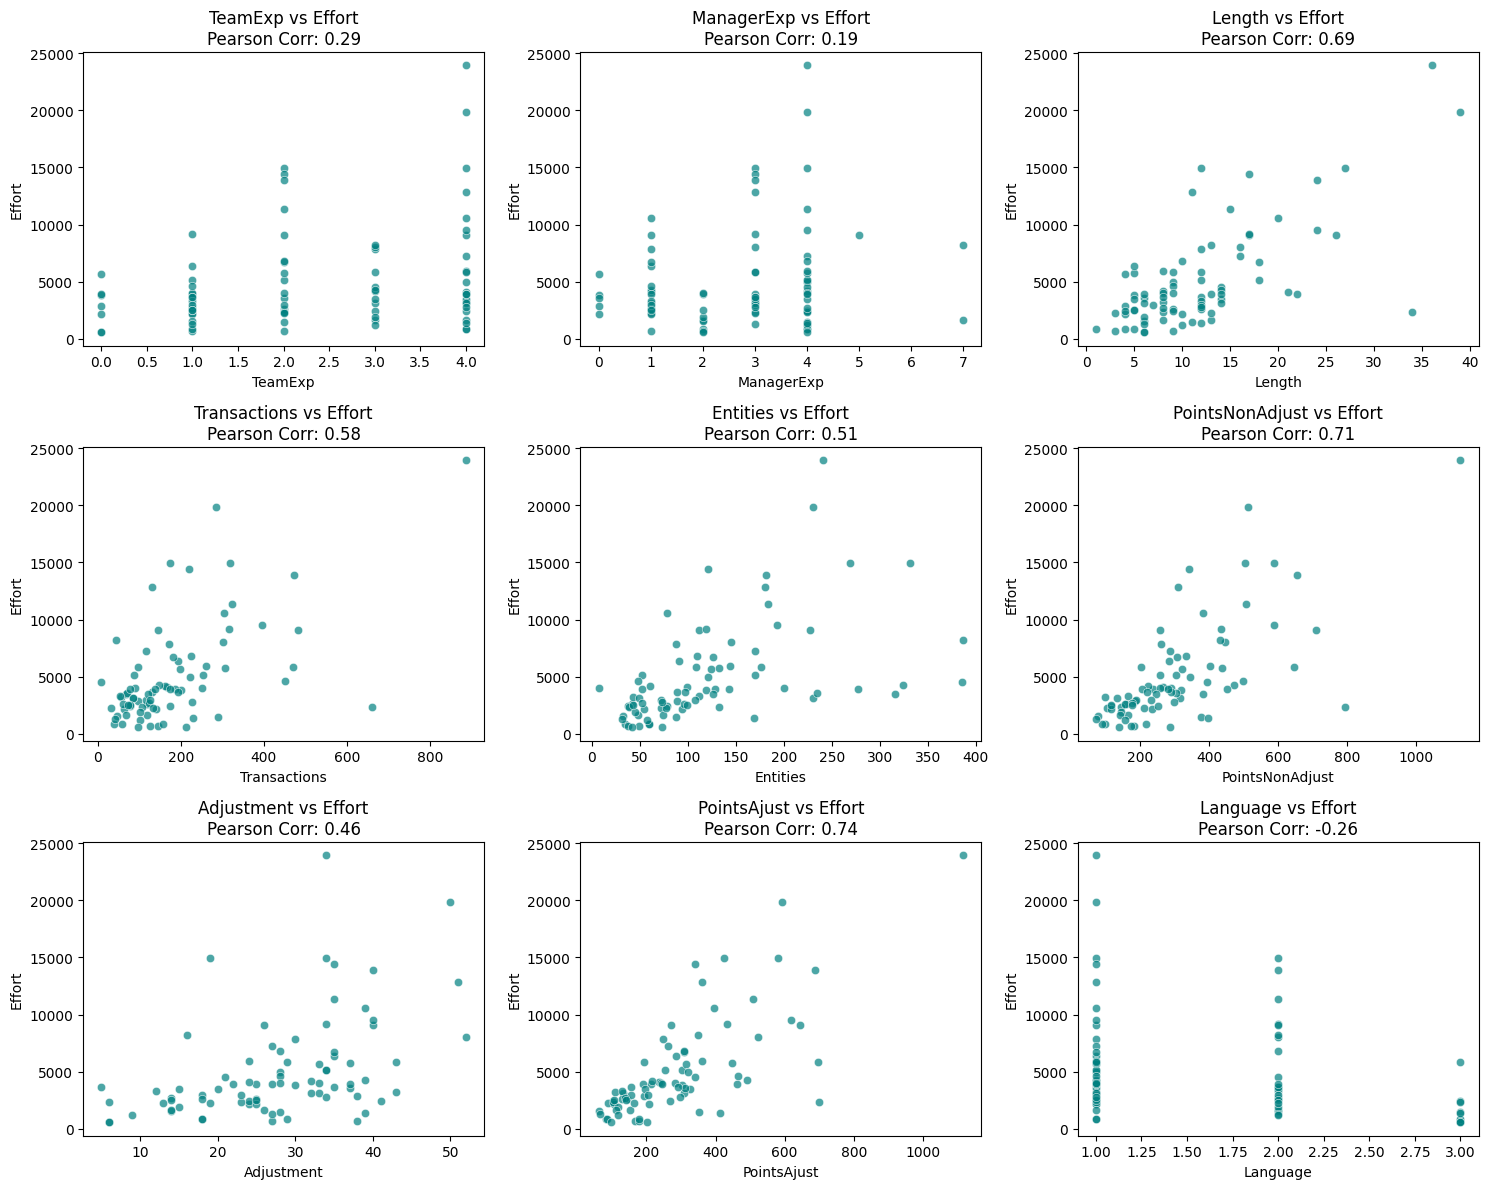

In [641]:
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 4 * rows))
axes = axes.flatten() # Aplanar el array de ejes para iterar fácilmente

# 6. Crear las gráficas iterando sobre las características
for i, feature in enumerate(features):
    # Crear el gráfico de dispersión
    sns.scatterplot(data=df, x=feature, y=target, ax=axes[i], color='teal', alpha=0.7)
    
    # Calcular la correlación de Pearson
    corr = df[feature].corr(df[target])
    
    # Añadir el título con el valor de la correlación
    axes[i].set_title(f'{feature} vs {target}\nPearson Corr: {corr:.2f}')

# 7. Ocultar los subplots vacíos (si el número de features no es múltiplo exacto de 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el diseño para que no se superpongan los títulos
plt.tight_layout()

# Guardar la gráfica como imagen (se guardará en la misma carpeta donde está tu notebook)
plt.savefig('graficas_correlacion.png', dpi=300, bbox_inches='tight')

print("¡Gráfica guardada exitosamente como 'graficas_correlacion.png'!")

In [610]:
df_numeric = df.select_dtypes(include=[np.number]).drop(columns=['id', 'Project'], errors='ignore')

In [611]:
categorias = ['Language', 'TeamExp', 'ManagerExp']
for col in categorias:
    df[col] = df[col].astype('category')

In [612]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   TeamExp          81 non-null     category
 1   ManagerExp       81 non-null     category
 2   Length           81 non-null     int64   
 3   Effort           81 non-null     int64   
 4   Transactions     81 non-null     int64   
 5   Entities         81 non-null     int64   
 6   PointsNonAdjust  81 non-null     int64   
 7   Adjustment       81 non-null     int64   
 8   PointsAjust      81 non-null     int64   
 9   Language         81 non-null     category
dtypes: category(3), int64(7)
memory usage: 4.9 KB


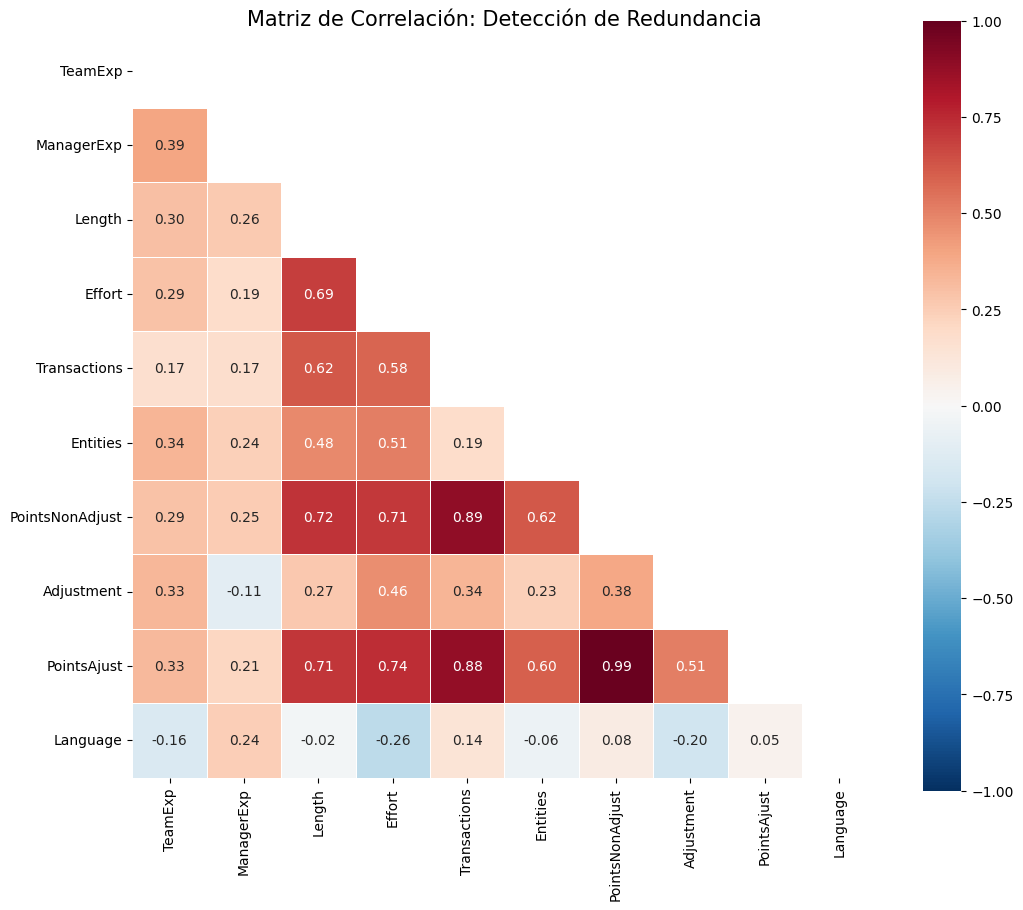

In [613]:
# 2. Calcular matriz
corr_matrix = df_numeric.corr()

# 3. Crear máscara para ocultar la mitad superior (evita duplicados visuales)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Graficar
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', fmt=".2f", 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title('Matriz de Correlación: Detección de Redundancia', fontsize=15)
plt.show()

# Información General y Estadísticos Descriptivos


In [614]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   TeamExp          81 non-null     category
 1   ManagerExp       81 non-null     category
 2   Length           81 non-null     int64   
 3   Effort           81 non-null     int64   
 4   Transactions     81 non-null     int64   
 5   Entities         81 non-null     int64   
 6   PointsNonAdjust  81 non-null     int64   
 7   Adjustment       81 non-null     int64   
 8   PointsAjust      81 non-null     int64   
 9   Language         81 non-null     category
dtypes: category(3), int64(7)
memory usage: 4.9 KB
None


Estadísticas Descriptivas (Variables Numéricas):

In [615]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Length,81.0,11.666667,7.424621,1.0,6.0,10.0,14.0,39.0
Effort,81.0,5046.308642,4418.767228,546.0,2352.0,3647.0,5922.0,23940.0
Transactions,81.0,182.123457,144.035098,9.0,88.0,140.0,224.0,886.0
Entities,81.0,122.333333,84.882124,7.0,57.0,99.0,169.0,387.0
PointsNonAdjust,81.0,304.456790,180.210159,73.0,176.0,266.0,384.0,1127.0
Adjustment,81.0,27.629630,10.591795,5.0,20.0,28.0,35.0,52.0
PointsAjust,81.0,289.234568,185.761088,62.0,152.0,255.0,351.0,1116.0


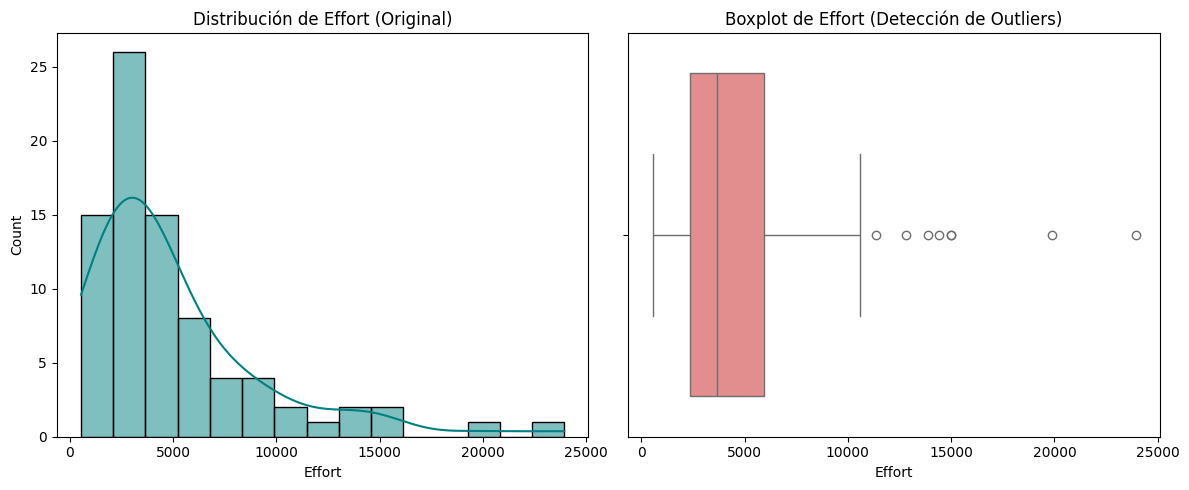

In [616]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Effort'], kde=True, color='teal')
plt.title('Distribución de Effort (Original)')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Effort'], color='lightcoral')
plt.title('Boxplot de Effort (Detección de Outliers)')
plt.tight_layout()
plt.show()

In [617]:
print(f"Dimensiones después de imputacion de valores faltantes: {df_clean.shape}")

Dimensiones después de imputacion de valores faltantes: (81, 10)


In [618]:
df_clean = df.copy()
df_clean.head()

,TeamExp,ManagerExp,Length,Effort,Transactions,Entities,PointsNonAdjust,Adjustment,PointsAjust,Language
0,1,4,12,5152,253,52,305,34,302,1
1,0,0,4,5635,197,124,321,33,315,1
2,4,4,1,805,40,60,100,18,83,1
3,0,0,5,3829,200,119,319,30,303,1
4,0,0,4,2149,140,94,234,24,208,1


In [619]:
df_clean.head()

,TeamExp,ManagerExp,Length,Effort,Transactions,Entities,PointsNonAdjust,Adjustment,PointsAjust,Language
0,1,4,12,5152,253,52,305,34,302,1
1,0,0,4,5635,197,124,321,33,315,1
2,4,4,1,805,40,60,100,18,83,1
3,0,0,5,3829,200,119,319,30,303,1
4,0,0,4,2149,140,94,234,24,208,1


# PARTICIÓN (70/30) Y ESCALADO (X e y)

In [620]:
features

['TeamExp',
 'ManagerExp',
 'Length',
 'Transactions',
 'Entities',
 'PointsNonAdjust',
 'Adjustment',
 'PointsAjust',
 'Language']

In [621]:

cols_continuas = ['Length', 'Transactions', 'Entities', 'PointsNonAdjust', 'Adjustment', 'PointsAjust']

cols_categoricas = ['Language', 'TeamExp', 'ManagerExp']

X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# %% 3. Escalar SOLO las características continuas
scaler_X = StandardScaler()

# Copiamos para mantener las categóricas intactas
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# El StandardScaler solo toca las continuas
X_train_scaled[cols_continuas] = scaler_X.fit_transform(X_train[cols_continuas])
X_test_scaled[cols_continuas] = scaler_X.transform(X_test[cols_continuas])

# %% 4. Escalar la variable objetivo (Effort)
scaler_y = StandardScaler()
y_train_scaled = pd.Series(scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten(), index=y_train.index)
y_test_scaled = pd.Series(scaler_y.transform(y_test.values.reshape(-1, 1)).flatten(), index=y_test.index)

# SELECCIÓN DE CARACTERÍSTICAS

In [622]:
corr_matrix_train = X_train_scaled.assign(**{target: y_train_scaled}).corr()
corr_target = corr_matrix_train[target].abs().sort_values(ascending=False).drop(target)

diferencias = np.diff(corr_target.values)
punto_corte = np.argmax(diferencias) + 3 
top_features = corr_target.index[:punto_corte].tolist()

print(f"\n--- Características seleccionadas (Top {punto_corte}):", top_features)


--- Características seleccionadas (Top 4): ['PointsAjust', 'PointsNonAdjust', 'Length', 'Transactions']


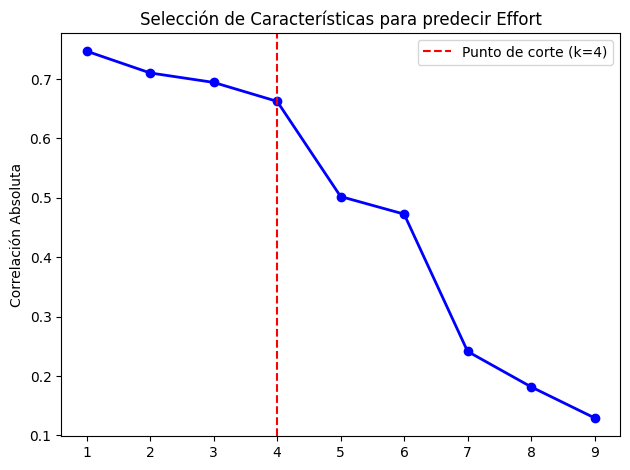

In [623]:
plt.plot(range(1, len(corr_target)+1), corr_target.values, 'bo-', linewidth=2)
plt.axvline(x=punto_corte, color='red', linestyle='--', label=f'Punto de corte (k={punto_corte})')
plt.title(f'Selección de Características para predecir {target}')
plt.ylabel('Correlación Absoluta')
plt.legend()
plt.tight_layout()
plt.show()


--- Importancia de Características (Árboles):
Length             0.5534
Transactions       0.2188
Language           0.0773
PointsAjust        0.0634
Entities           0.0321
PointsNonAdjust    0.0302
TeamExp            0.0171
Adjustment         0.0041
ManagerExp         0.0035
dtype: float64

--- Seleccionadas (Top 2): ['Length', 'Transactions']


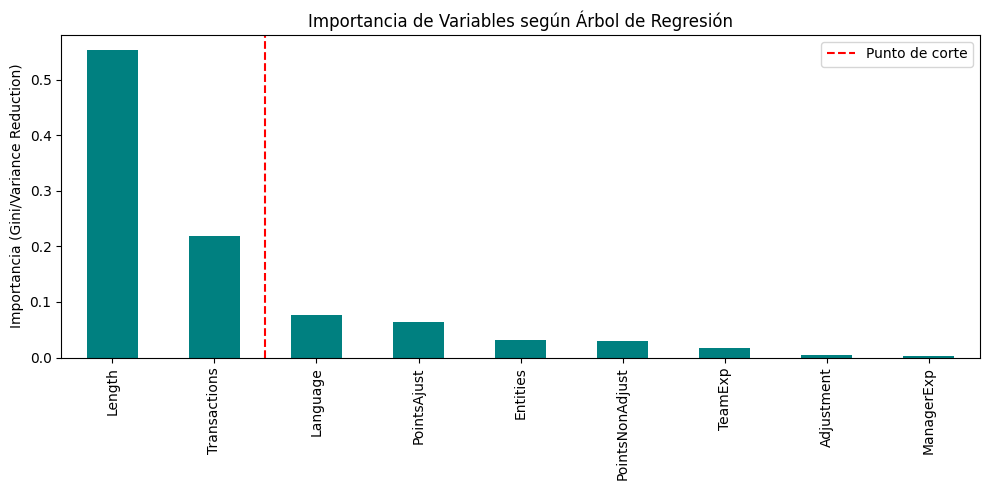

In [624]:

selector_tree = DecisionTreeRegressor(random_state=42)
selector_tree.fit(X_train_scaled, y_train_scaled)

# Extraer importancias y crear una serie
importancias = pd.Series(selector_tree.feature_importances_, index=features).sort_values(ascending=False)

# Definir punto de corte (ejemplo: variables que aportan más del 5% de importancia acumulada 
# o simplemente las top K que tú decidas)
# En este caso, usaremos el mismo concepto de "salto" o "codo" pero sobre las importancias
diferencias_imp = np.diff(importancias.values)
punto_corte_imp = np.argmax(np.abs(diferencias_imp)) + 2
top_features_tree = importancias.index[:punto_corte_imp].tolist()

print(f"\n--- Importancia de Características (Árboles):")
print(importancias.round(4))
print(f"\n--- Seleccionadas (Top {punto_corte_imp}): {top_features_tree}")

# Gráfica de Importancia
plt.figure(figsize=(10, 5))
importancias.plot(kind='bar', color='teal')
plt.axvline(x=punto_corte_imp - 0.5, color='red', linestyle='--', label='Punto de corte')
plt.title('Importancia de Variables según Árbol de Regresión')
plt.ylabel('Importancia (Gini/Variance Reduction)')
plt.legend()
plt.tight_layout()
plt.show()

# Seleccion de conjunto con todas las caracteristicas, y con las que son mejores

In [625]:
X_train_all = X_train_scaled
X_test_all = X_test_scaled

X_train_best = X_train_scaled[top_features]
X_test_best = X_test_scaled[top_features]

X_train_best_t= X_train_scaled[top_features_tree]
X_test_best_t = X_test_scaled[top_features_tree]

In [626]:
X_test_all.shape

(25, 9)

In [627]:
X_test_best.shape

(25, 4)

# Validacion cruzada

In [628]:
def imprimir_ecuacion_regresion(modelo, nombres_caracteristicas, titulo_modelo):
    """
    Función para imprimir los coeficientes e intercepto de un modelo
    de Regresión Lineal de forma legible.
    """
    print(f"\n{'='*60}")
    print(f" ECUACIÓN: {titulo_modelo}")
    print(f"{'='*60}")
    
    # Extraer el intercepto y los coeficientes
    intercepto = modelo.intercept_
    coeficientes = modelo.coef_
    
    # Comenzar a construir el string de la ecuación (recordando que y está escalada)
    print(f"Esfuerzo_Predicho (Escalado) = \n    {intercepto:.4f}")
    
    # Recorrer cada coeficiente y su nombre
    for coef, nombre in zip(coeficientes, nombres_caracteristicas):
        signo = "+" if coef >= 0 else "-"
        print(f"  {signo} {abs(coef):.4f} * ({nombre})")



In [629]:
def cross_validation_kfold_reg(X, y, modelo_base, grid_parametros, k=5, nombre_modelo=""):
    X_arr = np.array(X)
    y_arr = np.array(y)
    indices = np.arange(len(X_arr))
    np.random.shuffle(indices)
    bloques_indices = np.array_split(indices, k)
    
    gamma_opt = None
    menor_error_medio = float('inf')
    
    print(f"\n--- Iniciando K-FOLD (k={k}) | Caso: {nombre_modelo} ---")
    
    for gamma in grid_parametros:
        print(f"\nEvaluando \u03B3: {gamma}")
        errores_k = []
        modelo_gamma = clone(modelo_base)
        modelo_gamma.set_params(**gamma)
        
        for i in range(k):
            idx_test = bloques_indices[i]
            idx_train = np.hstack([bloques_indices[j] for j in range(k) if j != i])
            
            modelo_gamma.fit(X_arr[idx_train], y_arr[idx_train])
            predicciones = modelo_gamma.predict(X_arr[idx_test])
            
            error_i = mean_squared_error(y_arr[idx_test], predicciones)
            errores_k.append(error_i)
            print(f"   -> Pliegue {i+1} | MSE: {error_i:.4f}")
        
        error_medio_gamma = np.mean(errores_k)
        print(f" => MSE medio E(\u03B3) = {error_medio_gamma:.4f}")
        
        if error_medio_gamma < menor_error_medio:
            menor_error_medio = error_medio_gamma
            gamma_opt = gamma
            
    print(f">>> \u03B3_opt elegido: {gamma_opt} (MSE mínimo: {menor_error_medio:.4f}) <<<")
    
    modelo_final = clone(modelo_base)
    modelo_final.set_params(**gamma_opt)
    modelo_final.fit(X_arr, y_arr)
    return modelo_final, gamma_opt, menor_error_medio

In [630]:
def leave_one_out_reg(X, y, modelo_base, grid_parametros, nombre_modelo=""):
    X_arr = np.array(X)
    y_arr = np.array(y)
    n = len(X_arr)
    
    gamma_opt = None
    menor_error_medio = float('inf')
    
    print(f"\n--- Iniciando LEAVE-ONE-OUT (n={n}) | Caso: {nombre_modelo} ---")
    
    for gamma in grid_parametros:
        print(f"Evaluando \u03B3: {gamma} ... ", end="")
        errores_n = []
        modelo_gamma = clone(modelo_base)
        modelo_gamma.set_params(**gamma)
        
        for i in range(n):
            X_test, y_test = X_arr[i:i+1], y_arr[i:i+1]
            X_train = np.delete(X_arr, i, axis=0)
            y_train = np.delete(y_arr, i, axis=0)
            
            modelo_gamma.fit(X_train, y_train)
            pred = modelo_gamma.predict(X_test)
            
            error_i = mean_squared_error(y_test, pred)
            errores_n.append(error_i)
        
        error_medio_gamma = np.mean(errores_n)
        print(f"MSE medio = {error_medio_gamma:.4f}")
        
        if error_medio_gamma < menor_error_medio:
            menor_error_medio = error_medio_gamma
            gamma_opt = gamma
            
    print(f">>> \u03B3_opt elegido: {gamma_opt} (MSE mínimo: {menor_error_medio:.4f}) <<<")
    
    modelo_final = clone(modelo_base)
    modelo_final.set_params(**gamma_opt)
    modelo_final.fit(X_arr, y_arr)
    return modelo_final, gamma_opt, menor_error_medio

In [631]:
dt_base = DecisionTreeRegressor(random_state=42)
rf_base = RandomForestRegressor(random_state=42)
lr_base = LinearRegression()

grid_dt = [{'max_depth': 3}, {'max_depth': 5}, {'max_depth': 10}, {'max_depth': None}]
grid_rf = [{'n_estimators': 10, 'max_depth': 5}, {'n_estimators': 50, 'max_depth': 10}]
grid_lr = [{}] 

modelos_finales = {}


# --- MODELOS A (Todas las variables) ---

In [632]:
print("="*70)

dt_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, dt_base, grid_dt, k=5)
rf_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, rf_base, grid_rf, k=5)
lr_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, lr_base, grid_lr, k=5)

modelos_finales['Árbol (Todas)'] = (dt_all, 'all')
modelos_finales['Random Forest (Todas)'] = (rf_all, 'all')
modelos_finales['Regresión Lineal (Todas)'] = (lr_all, 'all')




--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 0.4235
   -> Pliegue 2 | MSE: 0.2129
   -> Pliegue 3 | MSE: 0.5288
   -> Pliegue 4 | MSE: 1.3195
   -> Pliegue 5 | MSE: 0.6446
 => MSE medio E(γ) = 0.6259

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 0.5488
   -> Pliegue 2 | MSE: 0.3154
   -> Pliegue 3 | MSE: 0.6260
   -> Pliegue 4 | MSE: 1.5510
   -> Pliegue 5 | MSE: 0.5834
 => MSE medio E(γ) = 0.7249

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 0.2903
   -> Pliegue 2 | MSE: 0.1366
   -> Pliegue 3 | MSE: 0.6940
   -> Pliegue 4 | MSE: 1.7112
   -> Pliegue 5 | MSE: 0.5733
 => MSE medio E(γ) = 0.6811

Evaluando γ: {'max_depth': None}
   -> Pliegue 1 | MSE: 0.2903
   -> Pliegue 2 | MSE: 0.0737
   -> Pliegue 3 | MSE: 0.6212
   -> Pliegue 4 | MSE: 1.7112
   -> Pliegue 5 | MSE: 0.5733
 => MSE medio E(γ) = 0.6539
>>> γ_opt elegido: {'max_depth': 3} (MSE mínimo: 0.6259) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'n

In [633]:
# 1. Imprimir Regresión Lineal con TODAS las variables
# Asumimos que X_train_all es un DataFrame que conserva los nombres de las columnas
imprimir_ecuacion_regresion(lr_all, X_train_all.columns, "Regresión Lineal A (Todas las variables)")


 ECUACIÓN: Regresión Lineal A (Todas las variables)
Esfuerzo_Predicho (Escalado) = 
    0.7214
  - 0.0888 * (TeamExp)
  + 0.0694 * (ManagerExp)
  + 0.2499 * (Length)
  - 0.9415 * (Transactions)
  - 0.5296 * (Entities)
  - 0.9547 * (PointsNonAdjust)
  - 0.2009 * (Adjustment)
  + 2.9039 * (PointsAjust)
  - 0.4491 * (Language)


# --- MODELOS B (Mejores variables) ---


In [634]:
# --- MODELOS B (Mejores variables) ---
dt_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, dt_base, grid_dt, k=5)
rf_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, rf_base, grid_rf, k=5)
lr_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, lr_base, grid_lr, k=5)

modelos_finales['Árbol (Mejores)'] = (dt_best, 'best')
modelos_finales['Random Forest (Mejores)'] = (rf_best, 'best')
modelos_finales['Regresión Lineal (Mejores)'] = (lr_best, 'best')


--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 0.5357
   -> Pliegue 2 | MSE: 0.1667
   -> Pliegue 3 | MSE: 2.9093
   -> Pliegue 4 | MSE: 0.5031
   -> Pliegue 5 | MSE: 2.6287
 => MSE medio E(γ) = 1.3487

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 0.8432
   -> Pliegue 2 | MSE: 0.2177
   -> Pliegue 3 | MSE: 0.9432
   -> Pliegue 4 | MSE: 0.2460
   -> Pliegue 5 | MSE: 2.2458
 => MSE medio E(γ) = 0.8992

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 0.8827
   -> Pliegue 2 | MSE: 0.4796
   -> Pliegue 3 | MSE: 0.9574
   -> Pliegue 4 | MSE: 0.3658
   -> Pliegue 5 | MSE: 2.2251
 => MSE medio E(γ) = 0.9821

Evaluando γ: {'max_depth': None}
   -> Pliegue 1 | MSE: 0.8827
   -> Pliegue 2 | MSE: 0.4796
   -> Pliegue 3 | MSE: 0.9574
   -> Pliegue 4 | MSE: 0.2223
   -> Pliegue 5 | MSE: 2.2251
 => MSE medio E(γ) = 0.9534
>>> γ_opt elegido: {'max_depth': 5} (MSE mínimo: 0.8992) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'n

In [635]:
# 2. Imprimir Regresión Lineal con MEJORES variables (Correlación)
imprimir_ecuacion_regresion(lr_best, X_train_best.columns, "Regresión Lineal B (Mejores por Correlación)")


 ECUACIÓN: Regresión Lineal B (Mejores por Correlación)
Esfuerzo_Predicho (Escalado) = 
    0.0000
  + 1.9161 * (PointsAjust)
  - 1.5225 * (PointsNonAdjust)
  + 0.3389 * (Length)
  + 0.0937 * (Transactions)


# --- MODELOS C (Variables elegidas por Árboles) ---


In [636]:
dt_tree, _, _ = cross_validation_kfold_reg(X_train_best_t, y_train_scaled, dt_base, grid_dt, k=5, nombre_modelo="DT Tree-Selected")
rf_tree, _, _ = cross_validation_kfold_reg(X_train_best_t, y_train_scaled, rf_base, grid_rf, k=5, nombre_modelo="RF Tree-Selected")
lr_tree, _, _ = cross_validation_kfold_reg(X_train_best_t, y_train_scaled, lr_base, grid_lr, k=5, nombre_modelo="LR Tree-Selected")

modelos_finales['Árbol (Tree-Sel)'] = (dt_tree, 'tree')
modelos_finales['Random Forest (Tree-Sel)'] = (rf_tree, 'tree')
modelos_finales['Regresión Lineal (Tree-Sel)'] = (lr_tree, 'tree')


--- Iniciando K-FOLD (k=5) | Caso: DT Tree-Selected ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 2.0542
   -> Pliegue 2 | MSE: 2.6462
   -> Pliegue 3 | MSE: 0.5375
   -> Pliegue 4 | MSE: 0.7185
   -> Pliegue 5 | MSE: 0.4179
 => MSE medio E(γ) = 1.2749

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 2.2730
   -> Pliegue 2 | MSE: 2.3928
   -> Pliegue 3 | MSE: 0.2632
   -> Pliegue 4 | MSE: 1.0347
   -> Pliegue 5 | MSE: 0.2117
 => MSE medio E(γ) = 1.2351

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 2.2806
   -> Pliegue 2 | MSE: 2.8161
   -> Pliegue 3 | MSE: 0.2916
   -> Pliegue 4 | MSE: 1.2100
   -> Pliegue 5 | MSE: 0.2588
 => MSE medio E(γ) = 1.3714

Evaluando γ: {'max_depth': None}
   -> Pliegue 1 | MSE: 2.2803
   -> Pliegue 2 | MSE: 2.8161
   -> Pliegue 3 | MSE: 0.2880
   -> Pliegue 4 | MSE: 1.2081
   -> Pliegue 5 | MSE: 0.2625
 => MSE medio E(γ) = 1.3710
>>> γ_opt elegido: {'max_depth': 5} (MSE mínimo: 1.2351) <<<

--- Iniciando K-FOLD (k=5) | Caso: RF Tre

In [637]:
# 3. Imprimir Regresión Lineal con variables TREE-SELECTED (Árbol)
imprimir_ecuacion_regresion(lr_tree, X_train_best_t.columns, "Regresión Lineal C (Variables elegidas por Árbol)")


 ECUACIÓN: Regresión Lineal C (Variables elegidas por Árbol)
Esfuerzo_Predicho (Escalado) = 
    0.0000
  + 0.4520 * (Length)
  + 0.3439 * (Transactions)


EVALUACIÓN FINAL EN CONJUNTO DE PRUEBAS (30% TEST SET)

In [638]:
# =============================================================================
# 7. EVALUACIÓN FINAL (Métricas en Español - Estándar UTM)
# =============================================================================

def calcular_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

resultados = {}

for nombre, (modelo, tipo_datos) in modelos_finales.items():
    # Selección de conjunto de prueba según el tipo de entrenamiento
    if tipo_datos == 'all':
        X_test_eval = X_test_all
    elif tipo_datos == 'best':
        X_test_eval = X_test_best
    else: # tree
        X_test_eval = X_test_best_t
        
    y_pred_scaled = modelo.predict(X_test_eval)
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    # Cálculo de métricas oficiales [cite: 31, 46]
    mse_val = mean_squared_error(y_test_scaled, y_pred_scaled)
    
    resultados[nombre] = {
        'Error Cuadrático Medio (MSE)': mse_val,
        'Raíz del MSE (RMSE)': np.sqrt(mse_val),
        'Error Absoluto Medio (MAE)': mean_absolute_error(y_test_scaled, y_pred_scaled),
        'R-cuadrado (R2)': r2_score(y_test_scaled, y_pred_scaled)
    }

# Crear DataFrame y mostrar resultados
df_resultados = pd.DataFrame(resultados).T
print("\n--- EVALUACIÓN DE DESEMPEÑO DE MODELOS ---")
print(df_resultados.round(4))


--- EVALUACIÓN DE DESEMPEÑO DE MODELOS ---
                             Error Cuadrático Medio (MSE)  \
Árbol (Todas)                                      0.5783   
Random Forest (Todas)                              0.2874   
Regresión Lineal (Todas)                           0.3277   
Árbol (Mejores)                                    0.6120   
Random Forest (Mejores)                            0.3823   
Regresión Lineal (Mejores)                         0.3173   
Árbol (Tree-Sel)                                   0.6310   
Random Forest (Tree-Sel)                           0.6026   
Regresión Lineal (Tree-Sel)                        0.3761   

                             Raíz del MSE (RMSE)  Error Absoluto Medio (MAE)  \
Árbol (Todas)                             0.7605                      0.5752   
Random Forest (Todas)                     0.5361                      0.3775   
Regresión Lineal (Todas)                  0.5724                      0.4152   
Árbol (Mejores)          

C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\val

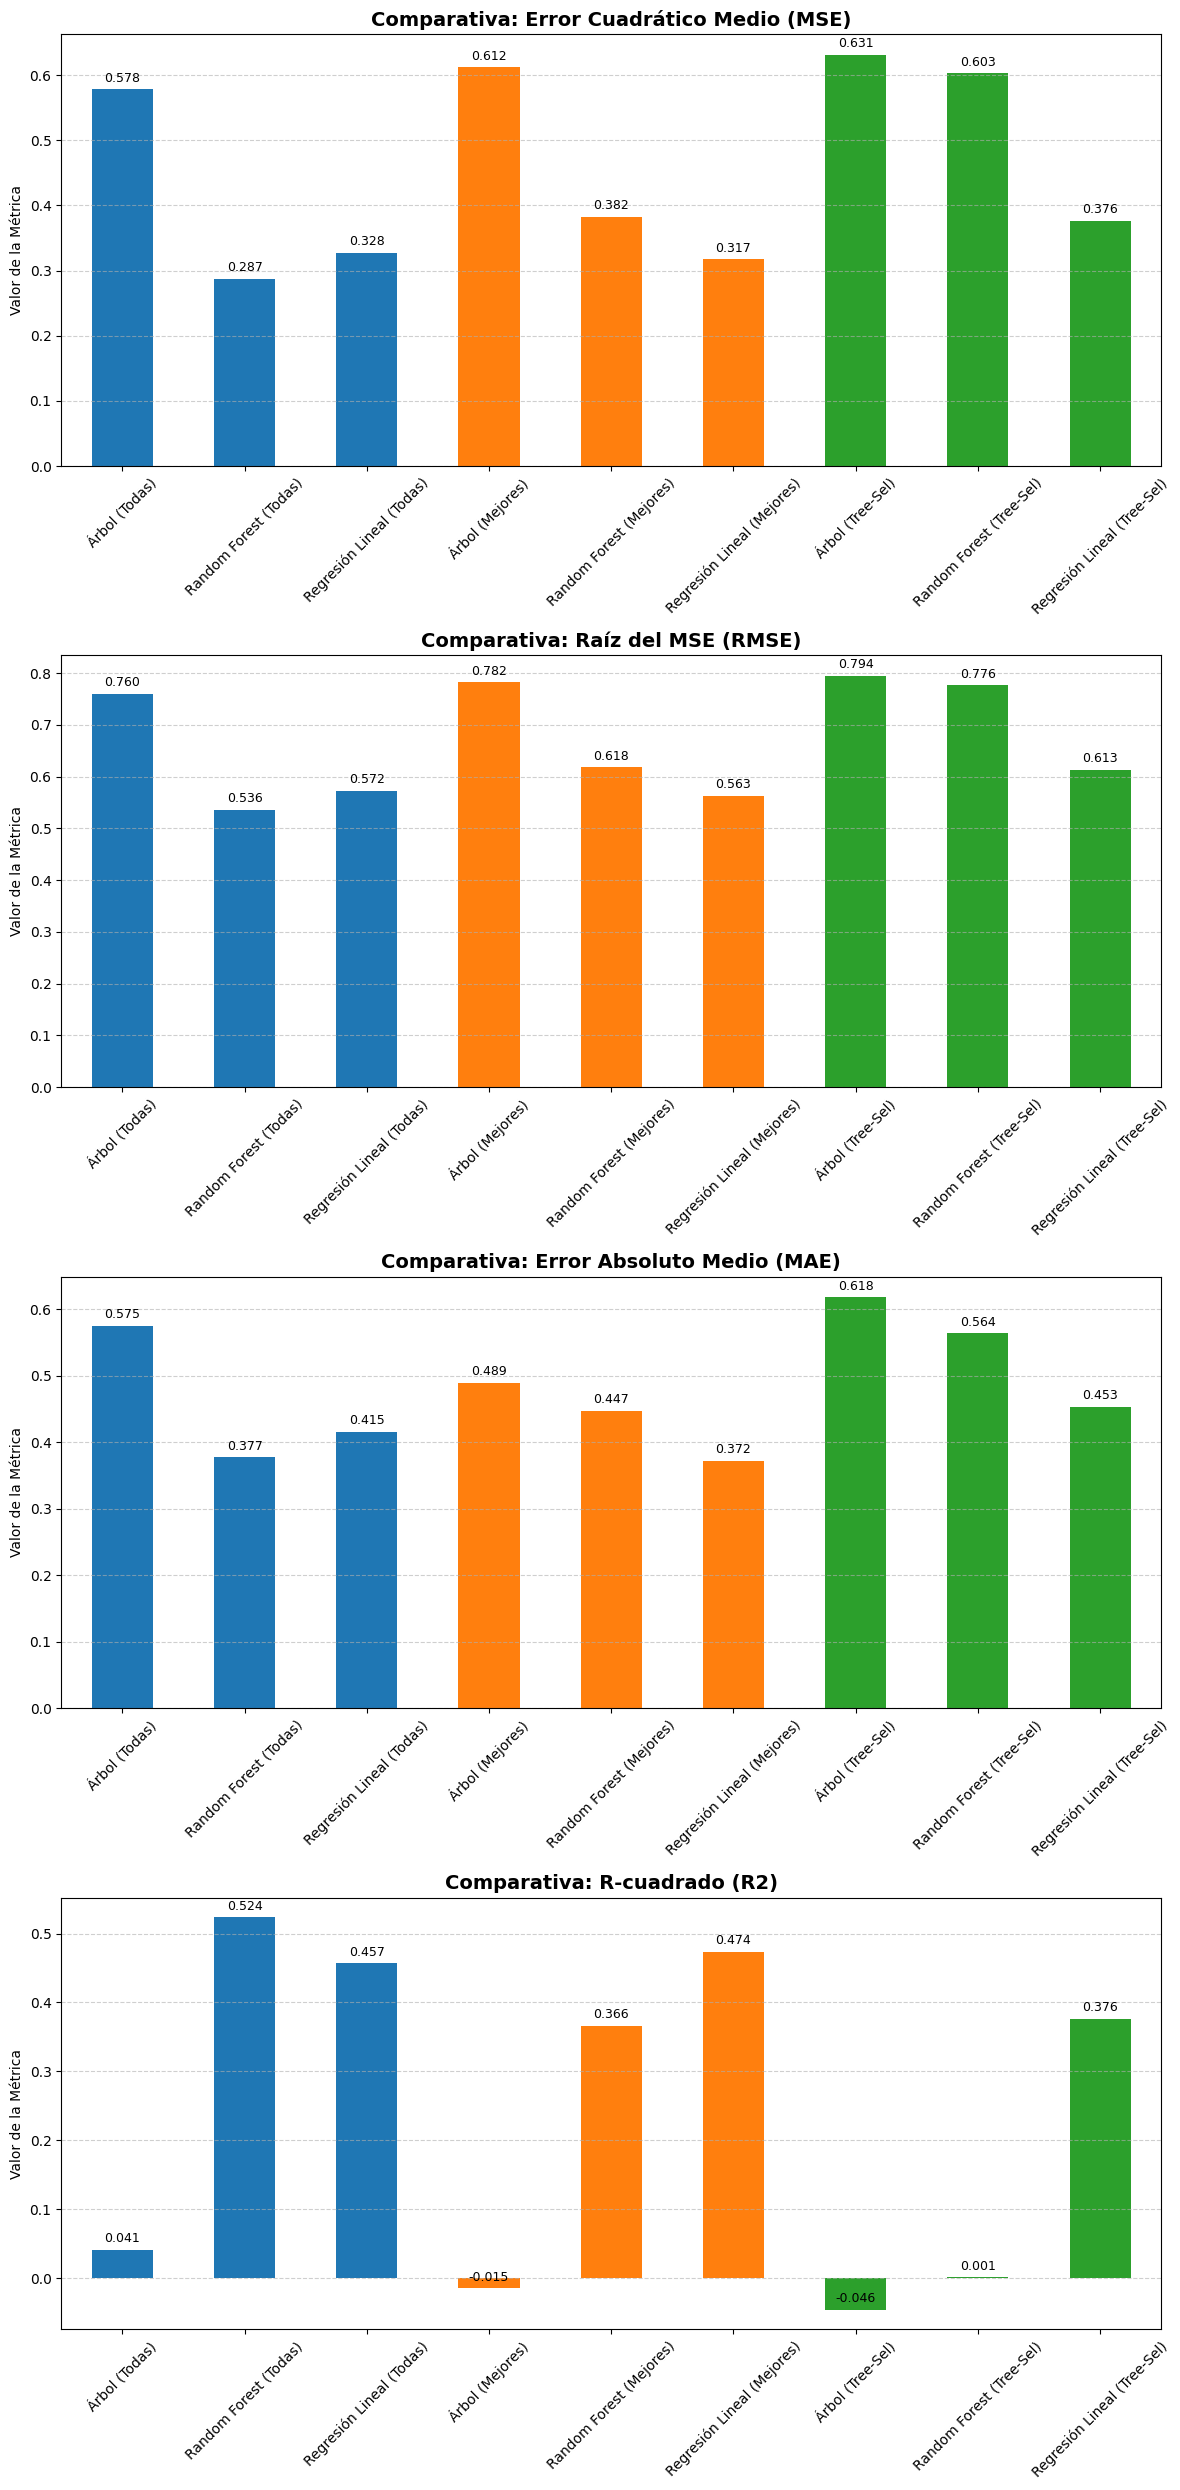

In [ ]:
# =============================================================================
# 8. GRÁFICAS COMPARATIVAS POR MÉTRICA (ESTÁNDAR DE EVALUACIÓN)
# =============================================================================

# Definimos las métricas que queremos graficar (las que calculamos antes)
metricas = ['Error Cuadrático Medio (MSE)', 'Raíz del MSE (RMSE)', 
            'Error Absoluto Medio (MAE)', 
            'R-cuadrado (R2)']

# Configuración de colores (Azul: Todas, Naranja: Corr, Verde: Tree, Rojo: LOOCV)
colores = ['#1f77b4']*3 + ['#ff7f0e']*3 + ['#2ca02c']*3 + ['#d62728']

# Creamos una figura con varios subplots (uno para cada métrica)
fig, axes = plt.subplots(nrows=len(metricas), ncols=1, figsize=(12, 25))

for i, metrica in enumerate(metricas):
    # Graficar en el subplot correspondiente
    df_resultados[metrica].plot(kind='bar', color=colores[:len(df_resultados)], ax=axes[i])
    
    axes[i].set_title(f'Comparativa: {metrica}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Valor de la Métrica')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
    
    # Añadir los valores numéricos arriba de las barras
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 8), 
                         textcoords='offset points',
                         fontsize=9)

plt.tight_layout()
plt.show()




==================== ITERACIÓN 1 ====================

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 1.3784
   -> Pliegue 2 | MSE: 0.3205
   -> Pliegue 3 | MSE: 0.8871
   -> Pliegue 4 | MSE: 0.1980
   -> Pliegue 5 | MSE: 1.2910
 => MSE medio E(γ) = 0.8150

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 1.5463
   -> Pliegue 2 | MSE: 0.2656
   -> Pliegue 3 | MSE: 1.1425
   -> Pliegue 4 | MSE: 0.1869
   -> Pliegue 5 | MSE: 1.3208
 => MSE medio E(γ) = 0.8924

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 1.4776
   -> Pliegue 2 | MSE: 0.3383
   -> Pliegue 3 | MSE: 1.2075
   -> Pliegue 4 | MSE: 0.3170
   -> Pliegue 5 | MSE: 1.3168
 => MSE medio E(γ) = 0.9314

Evaluando γ: {'max_depth': None}
   -> Pliegue 1 | MSE: 1.4776
   -> Pliegue 2 | MSE: 0.3383
   -> Pliegue 3 | MSE: 1.0028
   -> Pliegue 4 | MSE: 0.3170
   -> Pliegue 5 | MSE: 1.3168
 => MSE medio E(γ) = 0.8905
>>> γ_opt elegido: {'max_depth': 3} (MSE mínimo: 0.8150) <<<

--

C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\val

   -> Pliegue 2 | MSE: 0.7676
   -> Pliegue 3 | MSE: 0.8045
   -> Pliegue 4 | MSE: 0.4489
   -> Pliegue 5 | MSE: 0.7385
 => MSE medio E(γ) = 0.5626
>>> γ_opt elegido: {'n_estimators': 10, 'max_depth': 5} (MSE mínimo: 0.5208) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {}
   -> Pliegue 1 | MSE: 0.4758
   -> Pliegue 2 | MSE: 1.0072
   -> Pliegue 3 | MSE: 0.3009
   -> Pliegue 4 | MSE: 0.3848
   -> Pliegue 5 | MSE: 0.1449
 => MSE medio E(γ) = 0.4627
>>> γ_opt elegido: {} (MSE mínimo: 0.4627) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 0.2912
   -> Pliegue 2 | MSE: 1.4280
   -> Pliegue 3 | MSE: 1.3361
   -> Pliegue 4 | MSE: 0.3638
   -> Pliegue 5 | MSE: 2.9907
 => MSE medio E(γ) = 1.2820

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 0.5714
   -> Pliegue 2 | MSE: 1.4522
   -> Pliegue 3 | MSE: 1.3944
   -> Pliegue 4 | MSE: 0.6820
   -> Pliegue 5 | MSE: 3.9972
 => MSE medio E(γ) = 1.6195

Evaluando γ: {'max_depth': 1

C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\val


==================== ITERACIÓN 3 ====================

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 0.4961
   -> Pliegue 2 | MSE: 0.4561
   -> Pliegue 3 | MSE: 0.2411
   -> Pliegue 4 | MSE: 0.0451
   -> Pliegue 5 | MSE: 0.9359
 => MSE medio E(γ) = 0.4349

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 0.5642
   -> Pliegue 2 | MSE: 0.4637
   -> Pliegue 3 | MSE: 0.2603
   -> Pliegue 4 | MSE: 0.2584
   -> Pliegue 5 | MSE: 0.5967
 => MSE medio E(γ) = 0.4287

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 0.5318
   -> Pliegue 2 | MSE: 0.3708
   -> Pliegue 3 | MSE: 0.2538
   -> Pliegue 4 | MSE: 0.2347
   -> Pliegue 5 | MSE: 0.5678
 => MSE medio E(γ) = 0.3918

Evaluando γ: {'max_depth': None}
   -> Pliegue 1 | MSE: 0.5968
   -> Pliegue 2 | MSE: 0.4470
   -> Pliegue 3 | MSE: 0.2529
   -> Pliegue 4 | MSE: 0.2347
   -> Pliegue 5 | MSE: 0.4438
 => MSE medio E(γ) = 0.3950
>>> γ_opt elegido: {'max_depth': 10} (MSE mínimo: 0.3918) <<<

-

...

C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\val

   -> Pliegue 5 | MSE: 0.2146
 => MSE medio E(γ) = 0.6003
>>> γ_opt elegido: {'n_estimators': 50, 'max_depth': 10} (MSE mínimo: 0.6003) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {}
   -> Pliegue 1 | MSE: 0.3179
   -> Pliegue 2 | MSE: 0.5452
   -> Pliegue 3 | MSE: 0.6031
   -> Pliegue 4 | MSE: 0.7343
   -> Pliegue 5 | MSE: 0.9047
 => MSE medio E(γ) = 0.6210
>>> γ_opt elegido: {} (MSE mínimo: 0.6210) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 2.1109
   -> Pliegue 2 | MSE: 0.2158
   -> Pliegue 3 | MSE: 0.3647
   -> Pliegue 4 | MSE: 1.5040
   -> Pliegue 5 | MSE: 0.3678
 => MSE medio E(γ) = 0.9126

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 2.0873
   -> Pliegue 2 | MSE: 0.5130
   -> Pliegue 3 | MSE: 0.2655
   -> Pliegue 4 | MSE: 1.8899
   -> Pliegue 5 | MSE: 0.0554
 => MSE medio E(γ) = 0.9622

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 2.0882
   -> Pliegue 2 | MSE: 0.6947
   -> Pliegue 3 | MSE: 0.2

C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\val

   -> Pliegue 4 | MSE: 0.3232
   -> Pliegue 5 | MSE: 0.2645
 => MSE medio E(γ) = 0.5944

Evaluando γ: {'n_estimators': 50, 'max_depth': 10}
   -> Pliegue 1 | MSE: 1.5048
   -> Pliegue 2 | MSE: 0.5592
   -> Pliegue 3 | MSE: 0.2504
   -> Pliegue 4 | MSE: 0.2913
   -> Pliegue 5 | MSE: 0.3271
 => MSE medio E(γ) = 0.5865
>>> γ_opt elegido: {'n_estimators': 50, 'max_depth': 10} (MSE mínimo: 0.5865) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {}
   -> Pliegue 1 | MSE: 0.4757
   -> Pliegue 2 | MSE: 0.4757
   -> Pliegue 3 | MSE: 0.2771
   -> Pliegue 4 | MSE: 0.3367
   -> Pliegue 5 | MSE: 0.4602
 => MSE medio E(γ) = 0.4051
>>> γ_opt elegido: {} (MSE mínimo: 0.4051) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 1.2324
   -> Pliegue 2 | MSE: 0.7306
   -> Pliegue 3 | MSE: 0.3426
   -> Pliegue 4 | MSE: 0.2534
   -> Pliegue 5 | MSE: 0.5906
 => MSE medio E(γ) = 0.6299

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 1.3386
   -> 

C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\val

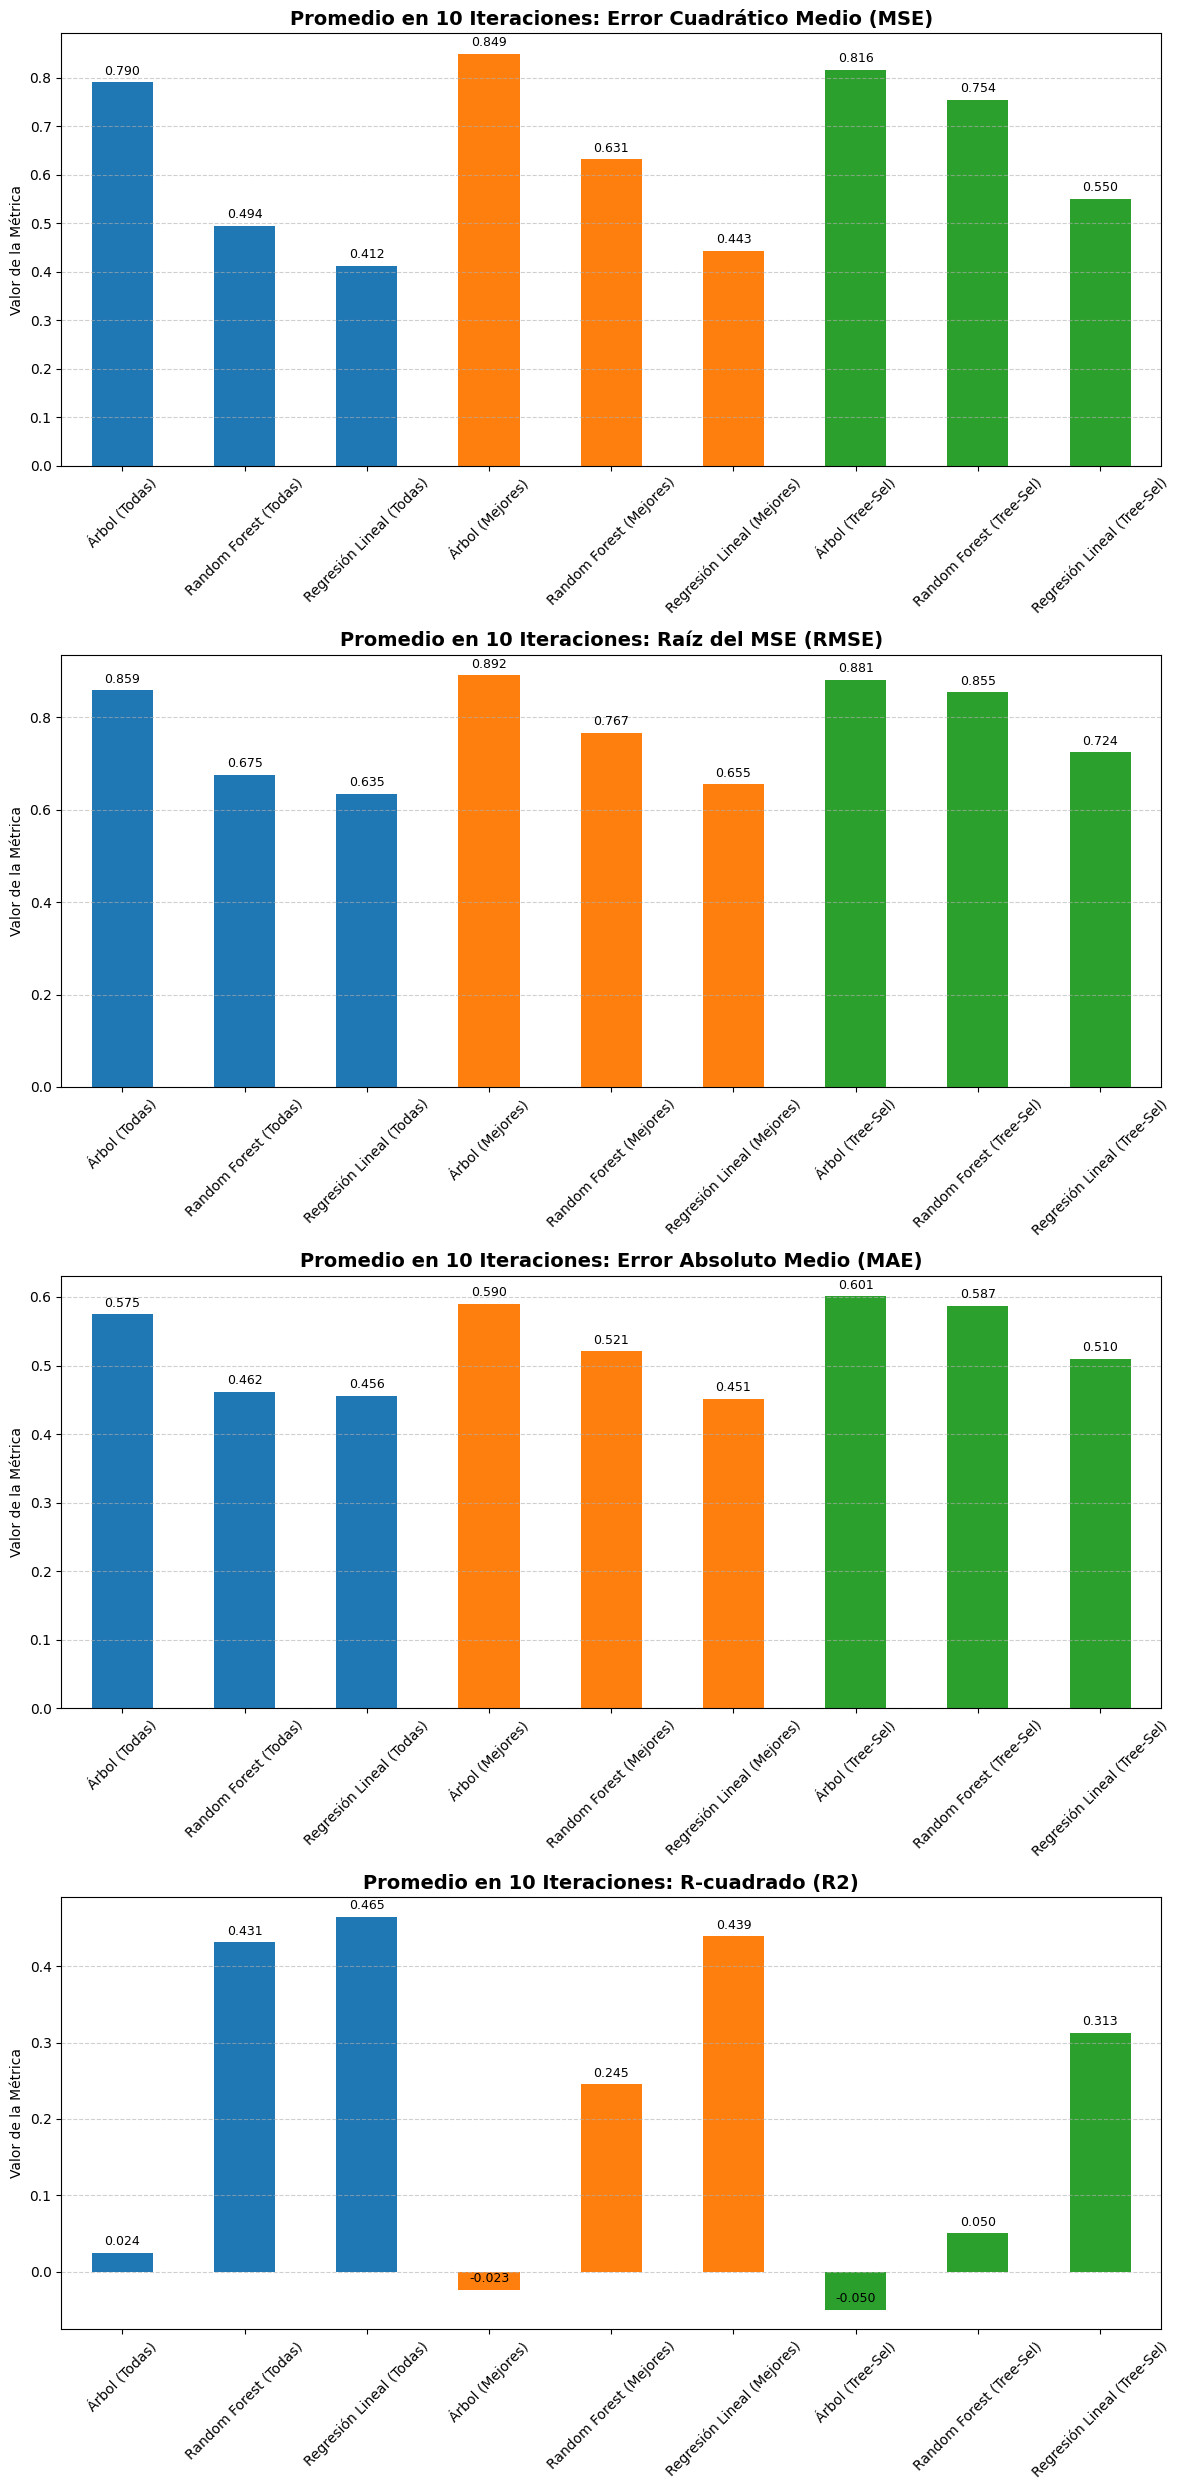

In [642]:
# Definición explícita de vectores con las características extraídas
top_features = ['PointsAjust', 'PointsNonAdjust', 'Length', 'Transactions']
top_features_tree = ['Length', 'Transactions']

n_iteraciones = 10

# Bucle principal
for i in range(n_iteraciones):
    print(f"\n{'='*20} ITERACIÓN {i+1} {'='*20}")
    
    cols_continuas = ['Length', 'Transactions', 'Entities', 'PointsNonAdjust', 'Adjustment', 'PointsAjust']
    cols_categoricas = ['Language', 'TeamExp', 'ManagerExp']

    X = df_clean[features]
    y = df_clean[target]
    
    # 1. PARTICIÓN
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i)

    # 2. Escalar SOLO las características continuas
    scaler_X = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[cols_continuas] = scaler_X.fit_transform(X_train[cols_continuas])
    X_test_scaled[cols_continuas] = scaler_X.transform(X_test[cols_continuas])

    # 3. Escalar la variable objetivo
    scaler_y = StandardScaler()
    y_train_scaled = pd.Series(scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten(), index=y_train.index)
    y_test_scaled = pd.Series(scaler_y.transform(y_test.values.reshape(-1, 1)).flatten(), index=y_test.index)

    # 4. Asignación de los subconjuntos completos (Todas)
    X_train_all = X_train_scaled
    X_test_all = X_test_scaled

    # 5. Extracción explícita usando los vectores para Best (Correlación) y Best_t (Árbol)
    X_train_best = X_train_scaled[top_features]
    X_test_best = X_test_scaled[top_features]

    X_train_best_t = X_train_scaled[top_features_tree]
    X_test_best_t = X_test_scaled[top_features_tree]

    # --- ENTRENAMIENTO USANDO TU FUNCIÓN ---
    # Modelos A (Todas)
    dt_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, dt_base, grid_dt, k=5)
    rf_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, rf_base, grid_rf, k=5)
    lr_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, lr_base, grid_lr, k=5)

    # Modelos B (Mejores)
    dt_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, dt_base, grid_dt, k=5)
    rf_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, rf_base, grid_rf, k=5)
    lr_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, lr_base, grid_lr, k=5)

    # Modelos C (Tree-Sel)
    dt_tree, _, _ = cross_validation_kfold_reg(X_train_best_t, y_train_scaled, dt_base, grid_dt, k=5)
    rf_tree, _, _ = cross_validation_kfold_reg(X_train_best_t, y_train_scaled, rf_base, grid_rf, k=5)
    lr_tree, _, _ = cross_validation_kfold_reg(X_train_best_t, y_train_scaled, lr_base, grid_lr, k=5)

    # --- EVALUACIÓN EN CONJUNTO DE PRUEBA Y ALMACENAMIENTO ---
    modelos_eval = {
        'Árbol (Todas)': (dt_all, X_test_all),
        'Random Forest (Todas)': (rf_all, X_test_all),
        'Regresión Lineal (Todas)': (lr_all, X_test_all),
        'Árbol (Mejores)': (dt_best, X_test_best),
        'Random Forest (Mejores)': (rf_best, X_test_best),
        'Regresión Lineal (Mejores)': (lr_best, X_test_best),
        'Árbol (Tree-Sel)': (dt_tree, X_test_best_t),
        'Random Forest (Tree-Sel)': (rf_tree, X_test_best_t),
        'Regresión Lineal (Tree-Sel)': (lr_tree, X_test_best_t)
    }

    for nombre, (modelo, X_test_eval) in modelos_eval.items():
        y_pred_scaled = modelo.predict(X_test_eval)
        mse_val = mean_squared_error(y_test_scaled, y_pred_scaled)
        
        metricas_acumuladas[nombre]['MSE'].append(mse_val)
        metricas_acumuladas[nombre]['RMSE'].append(np.sqrt(mse_val))
        metricas_acumuladas[nombre]['MAE'].append(mean_absolute_error(y_test_scaled, y_pred_scaled))
        metricas_acumuladas[nombre]['R2'].append(r2_score(y_test_scaled, y_pred_scaled))

# --- CÁLCULO DE PROMEDIOS FINALES ---
resultados_promedio = {}
for nombre, metricas in metricas_acumuladas.items():
    resultados_promedio[nombre] = {
        'Error Cuadrático Medio (MSE)': np.mean(metricas['MSE']),
        'Raíz del MSE (RMSE)': np.mean(metricas['RMSE']),
        'Error Absoluto Medio (MAE)': np.mean(metricas['MAE']),
        'R-cuadrado (R2)': np.mean(metricas['R2'])
    }

df_resultados_promedio = pd.DataFrame(resultados_promedio).T
print("\n--- RESULTADOS PROMEDIO TRAS 10 ITERACIONES ---")
print(df_resultados_promedio.round(4))

# --- GRÁFICAS COMPARATIVAS CON LOS PROMEDIOS ---
metricas_plot = ['Error Cuadrático Medio (MSE)', 'Raíz del MSE (RMSE)', 
                 'Error Absoluto Medio (MAE)', 'R-cuadrado (R2)']

colores = ['#1f77b4']*3 + ['#ff7f0e']*3 + ['#2ca02c']*3

fig, axes = plt.subplots(nrows=len(metricas_plot), ncols=1, figsize=(12, 25))

for i, metrica in enumerate(metricas_plot):
    df_resultados_promedio[metrica].plot(kind='bar', color=colores, ax=axes[i])
    axes[i].set_title(f'Promedio en 10 Iteraciones: {metrica}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Valor de la Métrica')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
    
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 8), 
                         textcoords='offset points',
                         fontsize=9)

plt.tight_layout()
plt.show()